In [ ]:
import gurobipy as gp
import numpy as np
from gurobipy import GRB

                        ## Esercizio 4 del 16/07/2025

model = gp.Model()
n = 5
x = model.addVars(n,n, lb = 0, ub = GRB.INFINITY)
model.update()
model.getVars()

dist = np.array([
    [0, 5, 8, 6, 10],
    [5, 0, 4, 5, 9],
    [8, 4, 0, 6, 7],
    [6, 5, 6, 0, 5],
    [10, 9, 7, 5, 0]
])

cost = np.array([
    [0, 4, 6, 5, 7],
    [4, 0, 3, 4, 6],
    [6, 3, 0, 5, 5],
    [5, 4, 5, 0, 4],
    [7, 6, 5, 4, 0]
])

b = np.array([20, 50, 20, 40, 25])
m = np.array([35, 30, 25, 30, 35])

for i in range(n):
    model.addConstr( 0.1 * gp.quicksum(x[i,j] for j in range(n)) <= 80)

for i in range(n):
    model.addConstr( gp.quicksum( dist[i,j] * x[i,j] for j in range(n)) <= 200)

for i in range(n):
    model.addConstr( 0.2 * gp.quicksum( dist[i,j] * x[i,j] for j in range(n)) <= 100)

for i in range(n):
    model.addConstr( ( gp.quicksum( x[j,i] for j in range(n)) - 
    gp.quicksum( x[i,j] for j in range(n))) + b[i] <= m[i])

for i in range(n):
    for j in range(n):
        model.addConstr (x[i,j] <= 10)

model.setObjective(gp.quicksum ( x[i,j] * cost[i,j] for i in range(n) for j in range(n)), GRB.MINIMIZE)

# model.optimize()

# for v in model.getVars():
#    print(v.VarName,"->", v.x)
# print(f"Valore finale costo minimizzato  =",model.ObjVal)


##-------------------------------------------------------------->

                    ## Esercizio 3 del 16/07/2025

model = gp.Model()

n_var = 6

x = model.addMVar( n_var, lb = [0]*n_var, ub = GRB.INFINITY, vtype = GRB.INTEGER )
model.update()

model.addConstr(x[0] <= 6)
model.addConstr(x[1] <= 5)
model.addConstr(0.3 * (x[0] + x[1]) <= x[2] + x[3])
#   model.addConstr(x[4] <= 4)
model.addConstr(x[2] <= x[0] - x[4])
#model.addConstr(x[5] == 0)
model.addConstr(x[0] >= x[2])
model.addConstr(x[1] >= x[3])
##--Considerando anche B, avremo:
#   model.addConstr(x[5] <= 4)
model.addConstr(x[5] + x[4] <= 4)
model.addConstr(x[5] <= x[1])

model.setObjective(x[0] + x[1], GRB.MAXIMIZE)
model.optimize()

for v in model.getVars():
   print(v.VarName,"->", v.x)
print(f"Valore finale costo minimizzato  =",model.ObjVal)

Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 8 rows, 6 columns and 17 nonzeros (Max)
Model fingerprint: 0xc9fb3876
Model has 2 linear objective coefficients
Variable types: 0 continuous, 6 integer (0 binary)
Coefficient statistics:
  Matrix range     [3e-01, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+00, 6e+00]

Found heuristic solution: objective -0.0000000
Presolve removed 8 rows and 6 columns
Presolve time: 0.01s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.04 seconds (0.00 work units)
Thread count was 1 (of 8 available processors)

Solution count 2: 11 -0 

Optimal solution found (tolerance 1.00e-04)
Be

In [ ]:
## Esercizio 1 - Si implemen e si risolva con Gurobi il seguente problema 



import dis

import gurobipy as gp
from gurobipy import GRB, quicksum
import numpy as np

model = gp.Model()

x = model.addMVar(3, lb=0, ub=GRB.INFINITY)
model.update()
x
mat_const = np.array([[0.42, 0.6, 0.5],
                      [0.014, 0.02, 0],
                      [2, 0, 4],
                      [0.235, 0.05, 0.3],
                      [0, 1, 0],
                      [1, 0, 0],
                      [-0.05, 0.5, -0.1]])

obj = np.array([7, 6, 10])
mat_not = np.array([15, 0.2, 32, 6, 4, 7, 3])

model.addConstr(mat_const[:4] @ x <= mat_not[:4])
model.addConstr(mat_const[4] @ x >= mat_not[4])
model.addConstr(mat_const[5:] @ x <= mat_not[5:])

model.setObjective(obj @ x, GRB.MAXIMIZE)
# model.optimize()

# for v in model.getVars():
#    print(v.VarName,"->", v.x)
# print(f"Valore finale di guadagno =",model.ObjVal)


            ## Esercizio 2 - Si implemen e si risolva con Gurobi il seguente problema 
        
model = gp.Model()
x = model.addVars(5,10, lb = 0, ub = GRB.INFINITY)
model.update()

c = np.array([7, 3, 4, 5.2, 2.8, 6, 3.5, 4.9, 3.2, 2.5])

disp = np.array([50, 35, 17, 29, 12, 77, 20, 51, 31, 19])

b = np.array([38, 17, 21, 44, 29])

for i in range(10):
    model.addConstr(gp.quicksum(x[j, i] for j in range(5)) <= disp[i])

for j in range(5):
    model.addConstr(gp.quicksum(x[j,i] for i in range(10)) == b[j])

model.addConstr( c[1] * gp.quicksum(x[j,2] for j in range(5)) >= 50)

model.addConstr(c[4] * gp.quicksum(x[j,5] for i in range(10)) >= 25)

m = np.array([1, 3, 7, 9])
val=0
for l in m:
    val += gp.quicksum(x[j,l] for j in range(5))
model.addConstr(val <= 70)

model.addConstr(x[2,4] >= 5)

model.addConstr(x[3,8] >= 5)

model.setObjective( c[i] * gp.quicksum(x[j,i] for j in range(5) for i in range(10)))
model.optimize()


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 20 rows, 50 columns and 128 nonzeros (Min)
Model fingerprint: 0x2526c7e2
Model has 50 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 3e+01]
  Objective range  [3e+00, 3e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+00, 8e+01]

Presolve removed 4 rows and 0 columns
Presolve time: 0.01s
Presolved: 16 rows, 51 columns, 121 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.7232143e+01   3.869345e+01   0.000000e+00      0s
      20    3.7250000e+02   0.000000e+00   0.000000e+00      0s

Solved in 20 iterations and 0.01 seconds (0.00 work units)
Optimal objective  3.725000000e+02


In [ ]:
##16 giugno 2023 

## Esercizio 1 - Si implemen e si risolva con Gurobi il seguente problema 



import dis

import gurobipy as gp
from gurobipy import GRB, quicksum
import numpy as np

model = gp.Model()

x = model.addMVar(3, lb=0, ub=GRB.INFINITY)
model.update()
x
mat_const = np.array([[0.42, 0.6, 0.5],
                      [0.014, 0.02, 0],
                      [2, 0, 4],
                      [0.235, 0.05, 0.3],
                      [0, 1, 0],
                      [1, 0, 0],
                      [-0.05, 0.5, -0.1]])

obj = np.array([7, 6, 10])
mat_not = np.array([15, 0.2, 32, 6, 4, 7, 3])

model.addConstr(mat_const[:4] @ x <= mat_not[:4])
model.addConstr(mat_const[4] @ x >= mat_not[4])
model.addConstr(mat_const[5:] @ x <= mat_not[5:])

model.setObjective(obj @ x, GRB.MAXIMIZE)
# model.optimize()

# for v in model.getVars():
#    print(v.VarName,"->", v.x)
# print(f"Valore finale di guadagno =",model.ObjVal)


            ## Esercizio 2 - Si implemen e si risolva con Gurobi il seguente problema 
        
model = gp.Model()
x = model.addVars(5,10, lb = 0, ub = GRB.INFINITY)
model.update()

c = np.array([7, 3, 4, 5.2, 2.8, 6, 3.5, 4.9, 3.2, 2.5])

disp = np.array([50, 35, 17, 29, 12, 77, 20, 51, 31, 19])

b = np.array([38, 17, 21, 44, 29])

for i in range(10):
    model.addConstr(gp.quicksum(x[j, i] for j in range(5)) <= disp[i])

for j in range(5):
    model.addConstr(gp.quicksum(x[j,i] for i in range(10)) == b[j])

model.addConstr( c[1] * gp.quicksum(x[j,2] for j in range(5)) >= 50)

model.addConstr(c[4] * gp.quicksum(x[j,5] for j in range(5)) >= 25)

m = np.array([0, 2, 6, 8])
val=0
# for l in m:
#     val += gp.quicksum(x[j,l] for j in range(5))
# model.addConstr(val <= 70)

model.addConstr((gp.quicksum(x[j,0] for j in range(5)) + gp.quicksum(x[j,0] for j in range(5)) + gp.quicksum(x[j,0] for j in range(5)) +
                  gp.quicksum(x[j,0] for j in range(5)) ) <= 70)

model.addConstr(x[2,4] >= 5)

model.addConstr(x[3,8] >= 5)

model.setObjective(gp.quicksum( c[i] * x[j,i] for j in range(5) for i in range(10)), GRB.MINIMIZE)
model.optimize()
for v in model.getVars():
   print(v.VarName,"->", v.x)
print(f"Valore finale di guadagno =",model.ObjVal)


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 20 rows, 50 columns and 117 nonzeros (Min)
Model fingerprint: 0xeedc84ec
Model has 50 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 4e+00]
  Objective range  [3e+00, 7e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+00, 8e+01]

Presolve removed 5 rows and 0 columns
Presolve time: 0.01s
Presolved: 15 rows, 52 columns, 102 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.0000000e+01   2.057440e+01   0.000000e+00      0s
      18    5.0662143e+02   0.000000e+00   0.000000e+00      0s

Solved in 18 iterations and 0.02 seconds (0.00 work units)
Optimal objective  5.066214286e+02
C0 -> 0.0
C1 -> 0.0
C2 -> 9.07142857142857
C3 -> 0.0
C4 -> 0.0
C5

In [ ]:
## Martedì 18 luglio 2023 

## Esercizio 1 - Si implemen e si risolva con Gurobi il seguente problema 

model = gp.Model()

x=model.addMVar(3, lb=[0]*3, vtype=GRB.INTEGER)
#x=model.addMVar(3, lb=0, ub=GRB.INFINITY)
model.update()

c1 = np.array([[24, 27, 23],
              [2/6, 3/6, 25/60],
              [1/6, 15/60, 1/6],
              [8/6, 12/60, 15/60]])

c2 = np.array([4,5,6])

cof = np.array([800, 20, 18, 22])

obj = np.array([2500, 5000, 3000])

model.addConstr(c1 @ x <= cof)

model.addConstr(x[0] >= c2[0])
model.addConstr(x[1] >= c2[1])
model.addConstr(x[2] >= c2[2])

model.setObjective((obj @ x) -275, GRB.MAXIMIZE)

model.optimize()
for v in model.getVars():
   print(v.VarName,"->", v.x)
print(f"Valore finale di guadagno =",model.ObjVal)


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 7 rows, 3 columns and 15 nonzeros (Max)
Model fingerprint: 0xe6116f50
Model has 3 linear objective coefficients and an objective constant of 275
Variable types: 0 continuous, 3 integer (0 binary)
Coefficient statistics:
  Matrix range     [2e-01, 3e+01]
  Objective range  [3e+03, 5e+03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [4e+00, 8e+02]

Presolve removed 7 rows and 3 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 1 (of 8 available processors)

Solution count 1: 130725 

Optimal solution found (tolerance 1.00e-04)
Best objective 1.307250000000e+05, best bound 1.307250000000e+05, gap 0.0000%
C0 -> 4

In [ ]:
## Venerdì 30 gennaio 2026 


import gurobipy as gp
from gurobipy import GRB
import numpy as np

model = gp.Model()

x = model.addMVar(5, lb=[0]*5, ub=GRB.INFINITY)
model.update()

s = np.array([3, 2, 4, 5, 2])
p = np.array([8, 6, 10, 14, 5])
a = np.array([[2, 1, 0],
              [1, 2, 1],
              [3, 1, 1],
              [2, 3, 2],
              [1, 0, 2]])
i=np.array([20, 30, 10, 5, 0])

model.addConstr(x @ a[:,0] <= 150)
model.addConstr(x @ a[:,1] <= 130)
model.addConstr(x @ a[:,2] <= 90)
model.addConstr((x-i) @ s <= 220)
model.addConstr(x[0] >= 20)
model.addConstr(x[1] >= 30)
model.addConstr(x[2] >= 10)
model.addConstr(x[3] >= 5)
model.addConstr(x[3] <= 35)
model.addConstr(x[0] <= 2* x[1])
model.addConstr(x[3] + x[4] <= x[2])
model.addConstr(0.35 * gp.quicksum(x[:4]) <= 65)

model.setObjective(x @ p, GRB.MAXIMIZE)
model.optimize()

for v in model.getVars():
   print(v.VarName,"->", v.x)
print(f"Valore finale di guadagno =", model.ObjVal)


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 12 rows, 5 columns and 32 nonzeros (Max)
Model fingerprint: 0x1a2743c6
Model has 5 linear objective coefficients
Coefficient statistics:
  Matrix range     [3e-01, 5e+00]
  Objective range  [5e+00, 1e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+00, 4e+02]

Presolve removed 8 rows and 0 columns
Presolve time: 0.04s
Presolved: 4 rows, 5 columns, 16 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    7.9000000e+02   1.395117e+01   0.000000e+00      0s
       3    6.9727273e+02   0.000000e+00   0.000000e+00      0s

Solved in 3 iterations and 0.05 seconds (0.00 work units)
Optimal objective  6.972727273e+02
C0 -> 20.0
C1 -> 30.0
C2 -> 17.272727272727273
C3 -> 10.909090909090908


In [ ]:
#Mercoledì 17 settembre 2025 

##Esercizio 4.  

model = gp.Model()

x = model.addVars(4,5, lb=0, ub=GRB.INFINITY, vtype=GRB.BINARY)
model.update()
t = np.array([0, 15, 30, 45, 60])

for i in range(4):
   model.addConstr(gp.quicksum(x[i,j] for j in range(5)) == 1)

for j in range(5):
   model.addConstr(gp.quicksum(x[i,j] for i in range(4)) <= 2 )

for j in range(5):
   for k in range(5):
      if np.abs(j-k) <= 1:
         model.addConstr(x[0,j] + x[1,k] <= 1)

model.addConstr( ( gp.quicksum( (j) * x[2,j] for j in range(5))) <= ( gp.quicksum( (j) * x[3,j] for j in range(5))))


model.addConstr( ( (gp.quicksum(x[i,j] for i in range (4) for j in range(3))) - 
                (gp.quicksum(x[i,j] for i in range (4) for j in range(3,5))) ) <=1 )

model.addConstr( ( (gp.quicksum(x[i,j] for i in range (4) for j in range(3,5))) - 
                (gp.quicksum(x[i,j] for i in range (4) for j in range(3))) ) <=1 )

model.setObjective(gp.quicksum(x[i,j] * t[j]  for i in range (4) for j in range(5)), GRB.MINIMIZE)
model.optimize()

for v in model.getVars():
   if v.x != 0:
     print(v.VarName,"->", v.x)
print(f"Valore finale =", model.ObjVal)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 25 rows, 20 columns and 114 nonzeros (Min)
Model fingerprint: 0x1f77c898
Model has 16 linear objective coefficients
Variable types: 0 continuous, 20 integer (20 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+00]
  Objective range  [2e+01, 6e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+00]

Found heuristic solution: objective 90.0000000
Presolve removed 25 rows and 20 columns
Presolve time: 0.01s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.03 seconds (0.00 work units)
Thread count was 1 (of 8 available processors)

Solution count 1: 90 

Optimal solution found (tolerance 1.00e-04)
Best objective 9.000000000000e+01, best bound 9.000000000000e+01, g

In [ ]:
## Giovedì 28 Agosto 2025 
#Esercizio 3


from turtle import mode


model = gp.Model()

x=model.addMVar(4, lb=0)
model.update()
t = np.array([[2, 10, 4],
              [6, 20, 3],
              [7, 2, 20],
              [9, 7, 10]])

q = np.array([3000, 2000, 5000])
ore = np.array([10, 12, 20, 18])
p = np.array([20000, 25000, 40000, 35000])

model.addConstr(x@t[:,0] <= 3000)
#model.addConstr(x@t[:,1] <= 2000)
model.addConstr(x@t[:,2] <= 5000)
model.addConstr(12*x[1] <= 0.3*x@ore)
#--
m2_extra = model.addVar(lb=0)
model.addConstr(x @ t[:,1] <= 2000 + m2_extra)
#--

model.setObjective( (x@p) - (x@t[:,0]*100 + x@t[:,1]*150 + x@t[:,2]*200 + x@ore *1000) - 
                   (300 * m2_extra), GRB.MAXIMIZE) 

# model.optimize()
# for v in model.getVars():
#      print(v.VarName,"->", v.x)
# print(f"Valore finale =", model.ObjVal)



## Esercizio 4

model=gp.Model()
x=model.addVars(3,3, lb=0)
model.update()

c = np.array([[4, 6, 8],
              [5, 3, 6],
              [7, 4, 5]])
k = np.array([60, 70, 100])
e = np.array([[0.2, 0.3, 0.4],
              [0.25, 0.2, 0.35],
              [0.30, 0.25, 0.3]])
p = np.array([1, 1.5, 2])
d = np.array([40, 30, 50])

for j in range(3):
  model.addConstr(gp.quicksum(x[i,j] for i in range(3)) <= k[j])


model.addConstr(gp.quicksum(x[i,j] * e[i,j] for j in range(3) for i in range(3)) <= 60)
model.addConstr(x[2,1] >= 10)

for i in range(3):
  model.addConstr(gp.quicksum(x[i,j] for j in range(3)) == d[i])

model.setObjective(gp.quicksum(x[i,j]*(c[i,j]+p[j]) for j in range(3) for i in range(3)), GRB.MINIMIZE)
model.optimize()
# for v in model.getVars():
#      print(v.VarName,"->", v.x)
# print(f"Valore finale =", model.ObjVal)

x

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 8 rows, 9 columns and 28 nonzeros (Min)
Model fingerprint: 0x7d29364f
Model has 9 linear objective coefficients
Coefficient statistics:


  Matrix range     [2e-01, 1e+00]
  Objective range  [5e+00, 1e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 1e+02]

Presolve removed 1 rows and 0 columns
Presolve time: 0.01s
Presolved: 7 rows, 9 columns, 27 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.1000000e+02   2.500000e+00   0.000000e+00      0s
       1    6.2500000e+02   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.03 seconds (0.00 work units)
Optimal objective  6.250000000e+02


{(0, 0): <gurobi.Var C0 (value 40.0)>,
 (0, 1): <gurobi.Var C1 (value 0.0)>,
 (0, 2): <gurobi.Var C2 (value 0.0)>,
 (1, 0): <gurobi.Var C3 (value 10.0)>,
 (1, 1): <gurobi.Var C4 (value 20.0)>,
 (1, 2): <gurobi.Var C5 (value 0.0)>,
 (2, 0): <gurobi.Var C6 (value 0.0)>,
 (2, 1): <gurobi.Var C7 (value 50.0)>,
 (2, 2): <gurobi.Var C8 (value 0.0)>}

In [ ]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np
model = gp.Model()

x = model.addMVar(5, lb=0)

g = np.array([1, 1, 2, 0, 1])
c = np.array([100, 150, 200, 300, 50])
k = np.array([2, 3, 1, 0.5, -1])
v = np.array([5, 6, 8, 7, 4])

model.addConstr(c@x <= 10000)
model.addConstr(k@x <= 150)
model.addConstr(0.3 * gp.quicksum(x) <= x[2] + x[3])
model.addConstr(0.4 * gp.quicksum(x) <= x[0] + x[1])
model.addConstr(g@x <= 60)
model.addConstr(gp.quicksum(x[i] for i in range(4)) <= 80)
model.addConstr(x[4] <= 20)

model.setObjective(gp.quicksum(x[i] * v[i] for i in range(5)), GRB.MAXIMIZE)

model.optimize()
for v in model.getVars():
     print(v.VarName,"->", v.x)
print(f"Valore finale =", model.ObjVal)


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 7 rows, 5 columns and 29 nonzeros (Max)
Model fingerprint: 0x9960178b
Model has 5 linear objective coefficients


Coefficient statistics:
  Matrix range     [3e-01, 3e+02]
  Objective range  [4e+00, 8e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+01, 1e+04]

Presolve removed 1 rows and 0 columns
Presolve time: 0.01s
Presolved: 6 rows, 5 columns, 28 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    8.0000000e+02   1.200000e+03   0.000000e+00      0s
       3    3.8692308e+02   0.000000e+00   0.000000e+00      0s

Solved in 3 iterations and 0.02 seconds (0.00 work units)
Optimal objective  3.869230769e+02
C0 -> 30.25641025641025
C1 -> 0.0
C2 -> 4.871794871794875
C3 -> 16.666666666666668
C4 -> 20.0
Valore finale = 386.9230769230769


In [1]:
##Mercoledì 18 settembre 2024 

##Esercizio 3. 

from sqlite3 import Binary

import gurobipy as gp
from gurobipy import GRB
import numpy as np

model = gp.Model()

x = model.addVars(3,20, lb=0, vtype=GRB.BINARY)
b1 = model.addVar(lb=0)
b2 = model.addVar(lb=0)
b3 = model.addVar(lb=0)
model.update()

c = np.array([10, 20, 15, 10, 16, 9, 17, 13, 18, 14, 14, 16, 13, 18, 14, 16, 19, 13, 11, 17])
t = np.array([6, 8, 3, 12, 8, 5, 3, 10, 5, 2, 9, 7, 1, 6, 2, 2, 16, 7, 5, 4])
model.addConstr(gp.quicksum(x[0,j] * c[j] for j in range(20)) <= 80)
model.addConstr(gp.quicksum(x[1,j] * c[j] for j in range(20)) <= 170)
model.addConstr(gp.quicksum(x[2,j] * c[j] for j in range(20)) <= 50)

model.addConstr(gp.quicksum(x[0,j] * t[j] for j in range(20)) - gp.quicksum(x[1,j] * t[j] for j in range(20)) <= b1)
model.addConstr(gp.quicksum(x[1,j] * t[j] for j in range(20)) - gp.quicksum(x[0,j] * t[j] for j in range(20)) <= b1)

model.addConstr(gp.quicksum(x[0,j] * t[j] for j in range(20)) - gp.quicksum(x[2,j] * t[j] for j in range(20)) <= b2)
model.addConstr(gp.quicksum(x[2,j] * t[j] for j in range(20)) - gp.quicksum(x[0,j] * t[j] for j in range(20)) <= b2)

model.addConstr(gp.quicksum(x[1,j] * t[j] for j in range(20)) - gp.quicksum(x[2,j] * t[j] for j in range(20)) <= b3)
model.addConstr(gp.quicksum(x[2,j] * t[j] for j in range(20)) - gp.quicksum(x[1,j] * t[j] for j in range(20)) <= b3)

#---------------
for j in range(20):
    model.addConstr(
        gp.quicksum(x[i,j] for i in range(3)) == 1
    )
#-------
model.ModelSense = GRB.MINIMIZE
model.setObjectiveN(b1, index=0, priority=1)
model.setObjectiveN(b2, index=1, priority=1)
model.setObjectiveN(b3, index=2, priority=1)
 
# model.optimize()
# for v in model.getVars():
#      print(v.VarName,"->", v.x)
# print(f"Valore finale =", model.ObjVal)

# for i in range(3):
#      print(f"b{i+1}", model.getObjective(i).getValue())



#Esercizio 4


model = gp.Model()

x = model.addMVar(4, lb=0, ub=GRB.INFINITY)
model.update()
d = np.array([300, 200, 150])
b = np.array([1, 3, 2, 1])
v = np.array([4, 5, 9, 3])

model.addConstr(x@b <= 800)
for i in range(3):
  model.addConstr(x[i] <= d[i])

model.addConstr(x[3] >= 0.5 * gp.quicksum(x[:3]))
model.addConstr(x[0] + x[1] >= 0.4 * gp.quicksum(x))
model.addConstr(x[1] + x[2] <= x[0] + x[3])

model.setObjective(x@v , GRB.MAXIMIZE)
model.optimize()

for i in model.getVars():
   print(i.VarName ,i.x)
print("Vale = ", model.ObjVal)


Restricted license - for non-production use only - expires 2027-11-29
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 7 rows, 4 columns and 19 nonzeros (Max)
Model fingerprint: 0x1a1385cd
Model has 4 linear objective coefficients
Coefficient statistics:
  Matrix range     [4e-01, 3e+00]
  Objective range  [3e+00, 9e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+02, 8e+02]

Presolve removed 4 rows and 0 columns
Presolve time: 0.01s
Presolved: 3 rows, 4 columns, 11 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.3600000e+03   7.650000e+01   0.000000e+00      0s
       1    3.1333333e+03   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.02 seconds (0.00 work units)
Optimal objective  3.133333333e+03
C0 

# yo (exo1 primo appelo 2026)
Questo metodo non funziona, lo risolto finalmente con Copilot

In [ ]:
from ast import Name

import gurobipy as gp
from gurobipy import GRB
import numpy as np

model = gp.Model()

x = model.addMVar((3,3), lb=0, ub=GRB.INFINITY, name="x")
y = model.addMVar((3,3), lb=0, ub=GRB.INFINITY, name="y")
p= model.addMVar(3, lb=0, ub=GRB.INFINITY)

g = np.array([45, 80,72])
t1 =np.array([[2, 4, 3],
             [1, 2, 5],
             [3, 7, 6]])
t2 =np.array([[25, 30, 35],
             [20, 25, 30],
             [15, 20, 25]])

for k in range(3):
    model.addConstr(t1[0] @ x[k] <= 240 + p[k])

for k in range(3):
    model.addConstr(gp.quicksum(t1[1] * x[k] ) <= 270)
    model.addConstr(gp.quicksum(t1[2] * x[k] ) <= 420)

for i in range(3):
    for j in range(3):
        if i == 0:
            model.addConstr(x[i,j] == t2.T[i,j] + y[i,j])
        else:
            model.addConstr(x[i,j] + y[i-1,j] == t2.T[i,j] + y[i,j])

for i in range(3):
    model.addConstr(x[i,0] >= 20)

for i in range(3):
    model.addConstr(p[i] <= 40)

# for j in range(3):
#     model.addConstr(y[0,j] == 0)

for j in range(3):
    model.addConstr(y[2,j] == 0)

model.setObjective(gp.quicksum(x[i,j] * g[j]  for i in range(3) for j in range(3)) -
                   8* gp.quicksum(p[k] for k in range(3) ), GRB.MAXIMIZE)

model.optimize()
for i in model.getVars():
   print(i.VarName ,i.x)
print("Vale = ", model.ObjVal)


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 27 rows, 21 columns and 63 nonzeros (Max)
Model fingerprint: 0x464e93de
Model has 12 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 7e+00]
  Objective range  [8e+00, 8e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+01, 4e+02]

Presolve removed 18 rows and 11 columns
Presolve time: 0.02s
Presolved: 9 rows, 10 columns, 36 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.6173240e+04   2.786863e+01   0.000000e+00      0s
       3    1.4370000e+04   0.000000e+00   0.000000e+00      0s

Solved in 3 iterations and 0.04 seconds (0.00 work units)
Optimal objective  1.437000000e+04
x[0,0] 30.0
x[0,1] 20.0
x[0,2] 15.0
x[1,0] 40.0
x[1,1] 25.0
x[1,2] 

In [ ]:
##EXO 2  PRIMO APPELO 2026

import gurobipy as gp
import numpy as np
from gurobipy import GRB

model = gp.Model()
x = model.addMVar((2,2,3), lb=0, ub=GRB.INFINITY,name="x")
model.update()
# for i in model.getVars():
#    print(i.VarName )

d = np.array([80, 70, 60])

# for j in range(2):
model.addConstr(gp.quicksum(x[0,j,k] for j in range(2) for k in range(3)) == 120)

# for j in range(2):
model.addConstr(gp.quicksum(x[1,j,k] for j in range(2) for k in range(3)) == 90) #riverifica questi egalità

for k in range(3):
    model.addConstr(gp.quicksum(x[i,j,k] for i in range(2) for j in range(2) ) == d[k])

# for i in range(2):
model.addConstr(gp.quicksum(x[i,0,k] for i in range(2) for k in range(3)) <= 130)

# for i in range(2):
model.addConstr(gp.quicksum(x[i,1,k] for i in range(2) for k in range(3)) <= 100)

model.addConstr(gp.quicksum(x[1,1,k] for k in range(3)) <= 50)

model.setObjective(
    gp.quicksum(2 *x[0,0,k] + 4*x[0,1,k] + 3*x[1,0,k] + 2*x[1,1,k] for k in range(3)) +
    gp.quicksum( 2*x[i,0,0] + 5*x[i,0,1] + 3*x[i,0,2] + 4*x[i,1,0] + x[i,1,1] + 2*x[i,1,2] for i in range(2)),
    GRB.MAXIMIZE
)

model.optimize()

for i in model.getVars():
   print(i.VarName ,i.x)
print("Vale = ", model.ObjVal)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 8 rows, 12 columns and 39 nonzeros (Max)
Model fingerprint: 0x57677f37
Model has 12 linear objective coefficients


Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+00, 8e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+01, 1e+02]

Presolve removed 1 rows and 0 columns
Presolve time: 0.02s
Presolved: 7 rows, 12 columns, 33 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.5600000e+03   5.022875e+00   0.000000e+00      0s
       2    1.5400000e+03   0.000000e+00   0.000000e+00      0s

Solved in 2 iterations and 0.04 seconds (0.00 work units)
Optimal objective  1.540000000e+03
x[0,0,0] 0.0
x[0,0,1] 20.0
x[0,0,2] 0.0
x[0,1,0] 80.0
x[0,1,1] 0.0
x[0,1,2] 20.0
x[1,0,0] 0.0
x[1,0,1] 50.0
x[1,0,2] 40.0
x[1,1,0] 0.0
x[1,1,1] 0.0
x[1,1,2] 0.0
Vale =  1540.0


In [ ]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB

p = np.array([2.5, 0, 11, 4, 27, 8, 20, 15])
f2 = np.array([3, 2.7, 0.3, 0, 0])
f1 = np.array([2.8, 1.9, 0.7, 0.2, 0])

model = gp.Model()
x = model.addMVar((2,8), lb=0, ub=GRB.INFINITY)

for i in range(8):
    model.addConstr(f1[i] *  x[0,i] + f2[i] *  x[1,i] >= p[i] )

for i in range(8):
    model.addConstr(f1[i] *  x[0,i] + f2[i] *  x[1,i] <= 45 )

model.setObjective (gp.quicksum(x[i,j] for i in range(2) for j in range(8)) , GRB.MAXIMIZE)
model.optimize()


Warning for adding constraints: zero or small (< 1e-13) coefficients, ignored


IndexError: index 5 is out of bounds for axis 0 with size 5

In [ ]:
p = np.array([2.5, 0, 11, 4, 27, 8, 20, 15])

prismil = np.array([2.8, 1.9, 0.7, 0.2, 0])
cilindren = np.array([3, 2.7, 0.3, 0, 0])

model = gp.Model()

x = model.addMVar((2,8), lb=0, name="x")

for i in range(8):
    protein_i = gp.quicksum(
        prismil[i-t] * x[0,t] + cilindren[i-t] * x[1,t]
        for t in range(i+1)
        if i-t < 5
    )

    model.addConstr(protein_i >= p[i])
    model.addConstr(protein_i <= 45)

model.setObjective(
    gp.quicksum(x[f,t] for f in range(2) for t in range(8)),
    GRB.MINIMIZE
)

model.optimize()
for i in model.getVars():
   print(i.VarName ,i.x)
print("Vale = ", model.ObjVal)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 16 rows, 16 columns and 94 nonzeros (Min)
Model fingerprint: 0x517a942f
Model has 16 linear objective coefficients
Coefficient statistics:
  Matrix range     [2e-01, 3e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 5e+01]

Presolve removed 8 rows and 1 columns
Presolve time: 0.01s
Presolved: 8 rows, 22 columns, 53 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.093750e+01   0.000000e+00      0s
       6    1.8196912e+01   0.000000e+00   0.000000e+00      0s

Solved in 6 iterations and 0.02 seconds (0.00 work units)
Optimal objective  1.819691220e+01
x[0,0] 0.8928571428571429
x[0,1] 0.0
x[0,2] 3.7053571428571432
x[0,3]

# PROVA DEL 09 GENNAIO 2025
### ESERCIZIO 1
![Screenshot 2026-07-12 130143.png](<attachment:Screenshot 2026-07-12 130143.png>)
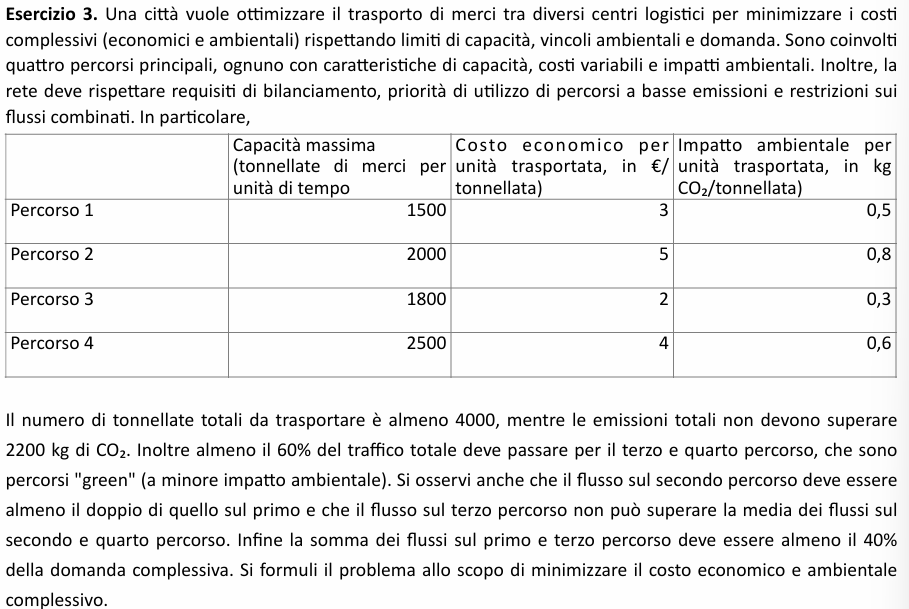

In [ ]:
from re import X

import gurobipy as gp
from gurobipy import GRB
import numpy as np

model = gp.Model()

x = model.addVars(4, lb=0, ub=GRB.INFINITY)
model.update()

cap = np.array([1500,2000,1800,2500])
imp = np.array([0.5,0.8,0.3,0.6])
obj = np.array([3,5,2,4])

model.addConstrs(x[i] <= cap[i] for i in range(4))
model.addConstr(gp.quicksum(x[i] for i in range(4)) >= 4000)
model.addConstr(gp.quicksum(x[i] * imp[i] for i in range(4)) <= 2200)
# model.addConstr( x @ imp <= 2200) -- funziona solo se avessi usato: x=model.addMvar 
model.addConstr(x[2] + x[3] >= 0.6 *(gp.quicksum(x[i] for i in range(4))) )
model.addConstr(x[1] >= 2*x[0] )
model.addConstr(x[2] <= 0.5 * (x[1] + x[3]) )
model.addConstr(x[0] + x[2] >= 0.4*(gp.quicksum(x[i] for i in range(4))))

model.setObjective(gp.quicksum(x[i] * obj[i] for i in range(4)) +
                   gp.quicksum(x[i] * imp[i] for i in range(4)) , GRB.MINIMIZE)
model.optimize()

for i in model.getVars():
    print( i.VarName,i.x)
print(model.ObjVal)


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 10 rows, 4 columns and 25 nonzeros (Min)
Model fingerprint: 0x699d6eb9
Model has 4 linear objective coefficients
Coefficient statistics:
  Matrix range     [3e-01, 2e+00]
  Objective range  [2e+00, 6e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+03, 4e+03]

Presolve removed 4 rows and 0 columns
Presolve time: 0.03s
Presolved: 6 rows, 4 columns, 21 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.000000e+03   0.000000e+00      0s
       4    1.6160000e+04   0.000000e+00   0.000000e+00      0s



Solved in 4 iterations and 0.04 seconds (0.00 work units)
Optimal objective  1.616000000e+04
C0 400.00000000000017
C1 800.0000000000003
C2 1200.0
C3 1599.9999999999995
16160.0


# PROVA DEL 09 GENNAIO 2025
### ESERCIZIO 2
![Screenshot 2026-07-12 142615.png](<attachment:Screenshot 2026-07-12 142615.png>)
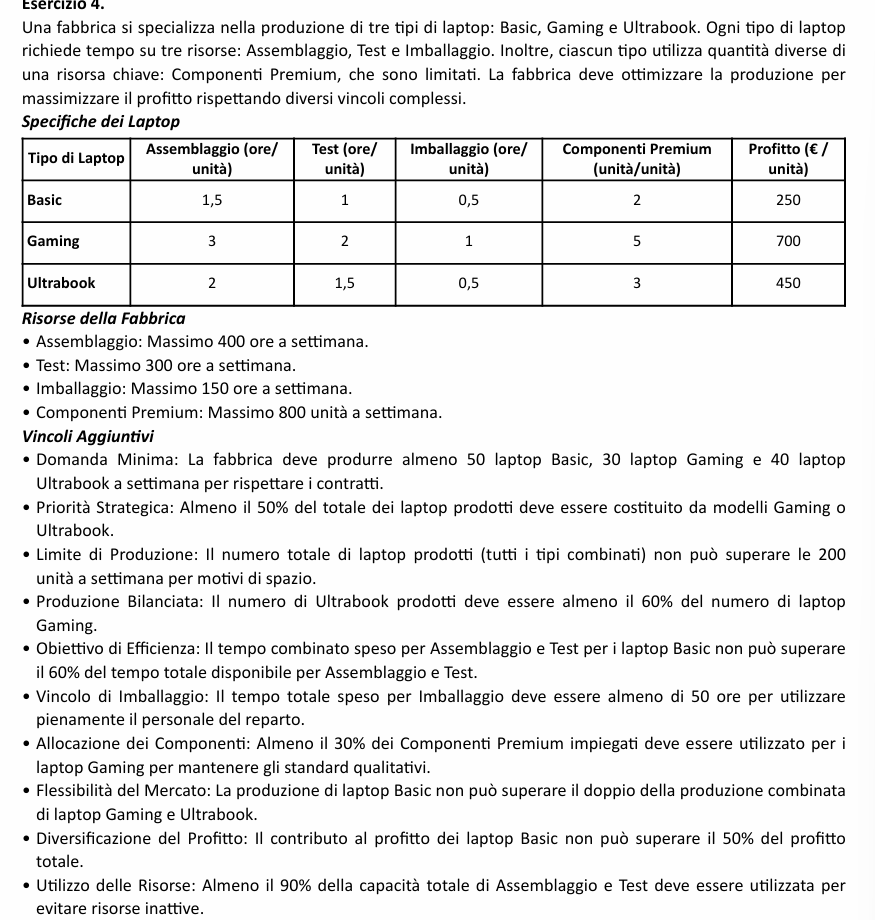

In [47]:
import ctypes


model = gp.Model()

x = model.addVars(3, lb=0, ub=GRB.INFINITY, vtype=GRB.INTEGER,name='x')
model.update()

a = np.array([1.5, 3, 2])
t = np.array([1, 2, 1.5])
im = np.array([0.5, 1, 0.5])
c = np.array([2, 5, 3])
p = np.array([250, 700, 450])

model.addConstr(gp.quicksum(a[i] * x[i] for i in range(3)) <= 400)
model.addConstr(gp.quicksum(t[i] * x[i] for i in range(3)) <= 300)
model.addConstr(gp.quicksum(im[i] * x[i] for i in range(3)) <= 150)
model.addConstr(gp.quicksum(c[i] * x[i] for i in range(3)) <= 800)

model.addConstr(x[0] >= 50)
model.addConstr(x[1] >= 30)
model.addConstr(x[2] >= 40)
model.addConstr(x[1] + x[2] >= 0.5*(x[0]+x[1]+x[2]))
model.addConstr(gp.quicksum( x[i] for i in range(3)) <= 200)
model.addConstr(x[2] >= 0.6*x[1])
model.addConstr(2.5* x[0] <= 0.6*700)
model.addConstr((x[0]/0.5 + x[1] + x[2]/0.5) >= 50)
model.addConstr(5* x[1] >= 0.3*(2*x[0] + 5*x[1] + 3*x[2]))
model.addConstr(x[0] <= 2 * (x[1]+x[2]))
model.addConstr(250 * x[0] <= 250*x[0] + 700*x[1] + 450*x[2])
model.addConstr(gp.quicksum( a[i] * x[i] for i in range(3)) >= 360)
model.addConstr(gp.quicksum( t[i] * x[i] for i in range(3)) >= 270)

model.setObjective(gp.quicksum(p[i] * x[i] for i in range(3)), GRB.MAXIMIZE)

model.optimize()



for i in model.getVars():
    print( i.VarName,i.x)
print(model.ObjVal)



Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 17 rows, 3 columns and 41 nonzeros (Max)
Model fingerprint: 0xfe08274b
Model has 3 linear objective coefficients
Variable types: 0 continuous, 3 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 7e+02]
  Objective range  [3e+02, 7e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+01, 8e+02]

Presolve removed 11 rows and 0 columns
Presolve time: 0.00s
Presolved: 6 rows, 3 columns, 17 nonzeros
Variable types: 0 continuous, 3 integer (0 binary)
Found heuristic solution: objective 87550.000000

Root relaxation: cutoff, 0 iterations, 0.00 seconds (0.00 work units)

Explored 1 nodes (0 simplex iterations) in 0.02 seconds (0.00 work units)
Thread count was 8 (of 8 available processors)

Solution coun

# PROVA DEL 18 settembre 2024 
### ESERCIZIO 3
![Screenshot 2026-07-14 234008.png](<attachment:Screenshot 2026-07-14 234008.png>)
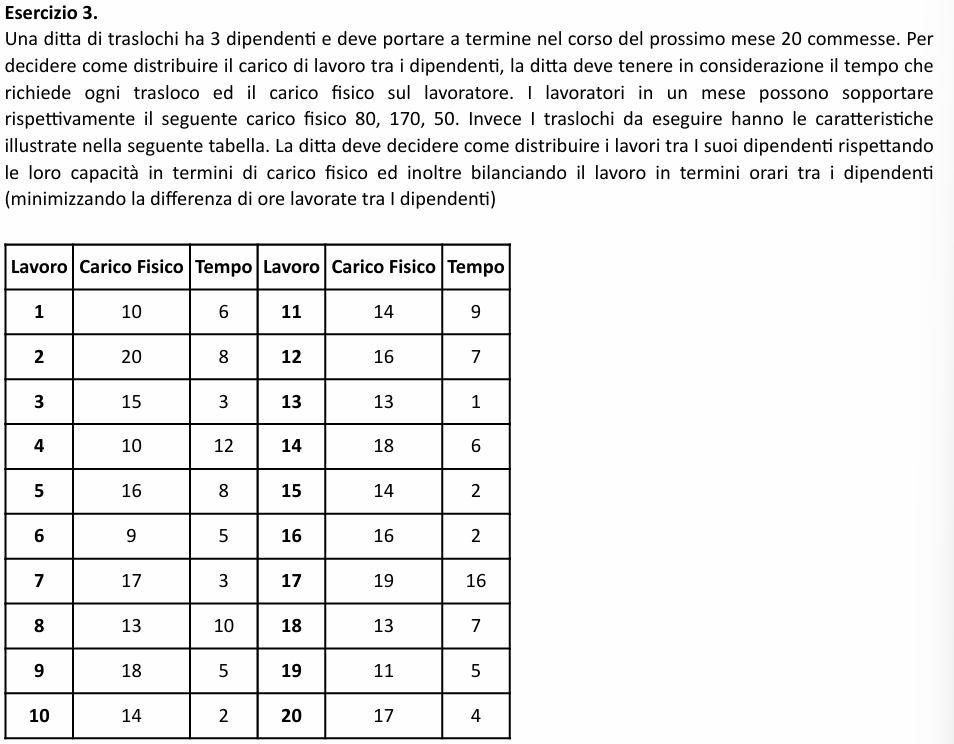

In [85]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

c_tot = np.array([80, 170, 50])
c = np.array([10, 20, 15, 10, 16, 9, 17, 13, 18, 14, 14, 16, 13, 18, 14, 16, 19, 13, 11, 17])
t = np.array([6, 8, 3, 12, 8, 5, 3, 10, 5, 2, 9, 7, 1, 6, 2, 2, 16, 7, 5, 4])

model = gp.Model()
y = model.addVars(3, lb=0, name="y")
x = model.addMVar((3,20), vtype=GRB.BINARY, name="x")
model.update()

model.addConstr(y[0] >= gp.quicksum(x[0,j] * t[j] for j in range(20)) -  
                        gp.quicksum(x[1,j] * t[j] for j in range(20))   )
model.addConstr(y[0] >= gp.quicksum(x[1,j] * t[j] for j in range(20)) -  
                        gp.quicksum(x[0,j] * t[j] for j in range(20))   )

model.addConstr(y[1] >= gp.quicksum(x[0,j] * t[j] for j in range(20)) -  
                        gp.quicksum(x[2,j] * t[j] for j in range(20))   )
model.addConstr(y[1] >= gp.quicksum(x[2,j] * t[j] for j in range(20)) -  
                        gp.quicksum(x[0,j] * t[j] for j in range(20))   )

model.addConstr(y[2] >= gp.quicksum(x[1,j] * t[j] for j in range(20)) -  
                        gp.quicksum(x[2,j] * t[j] for j in range(20))   )
model.addConstr(y[2] >= gp.quicksum(x[2,j] * t[j] for j in range(20)) -  
                        gp.quicksum(x[1,j] * t[j] for j in range(20))   )

for i in range(3):
    model.addConstr(gp.quicksum(x[i,j] * c[j] for j in range(20)) <= c_tot[i])   

for j in range(20):
    model.addConstr(gp.quicksum(x[i,j] for i in range(3)) == 1)               

model.setObjective(gp.quicksum(y[i] for i in range(3)), GRB.MINIMIZE)
model.optimize()
for i in range(3):
    print(y[i].varName, y[i].x)
print(model.ObjVal)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 29 rows, 63 columns and 366 nonzeros (Min)
Model fingerprint: 0x85578a1f
Model has 3 linear objective coefficients
Variable types: 3 continuous, 60 integer (60 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+02]

Found heuristic solution: objective 62.0000000
Presolve time: 0.00s
Presolved: 29 rows, 63 columns, 366 nonzeros
Variable types: 0 continuous, 63 integer (60 binary)

Root relaxation: objective 0.000000e+00, 38 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time


### ESERCIZIO 4
![Screenshot 2026-07-15 181123.png](<attachment:Screenshot 2026-07-15 181123.png>)

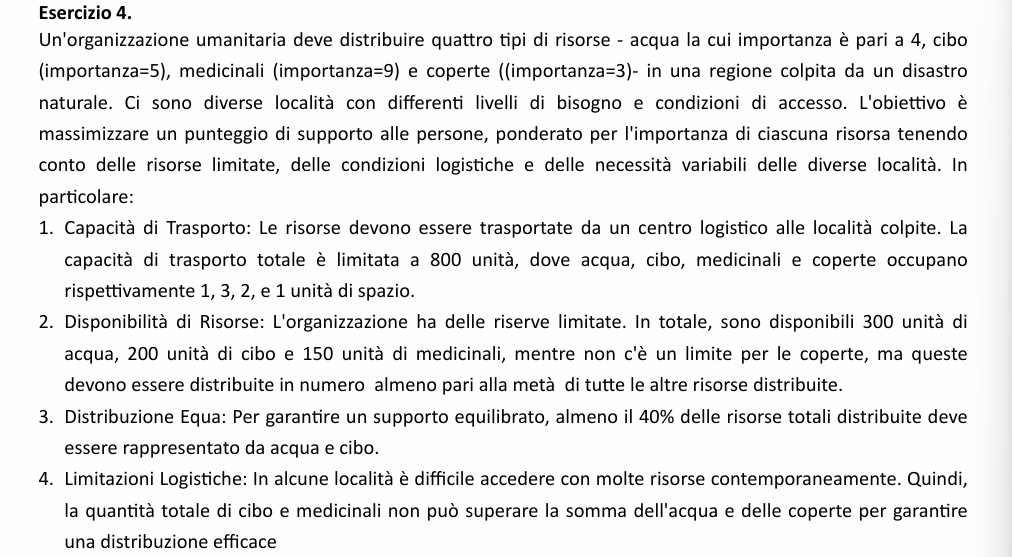

In [44]:
import gurobipy as gp
from gurobipy import GRB
import  numpy as np

model = gp.Model()
x = model.addVars(4, lb=0, ub=GRB.INFINITY, vtype=GRB.INTEGER)

imp = np.array([4, 5, 9, 3])
s = np.array([1, 3, 2, 1])

model.addConstr(gp.quicksum(s[i] * x[i] for i in range(4)) <= 800)
model.addConstr(x[0] <= 300)
model.addConstr(x[1] <= 200)
model.addConstr(x[2] <= 150)
model.addConstr(x[3] >= 0.5 * gp.quicksum(x[i] for i in range(3)))
model.addConstr(x[0] + x[1] >= 0.4 * gp.quicksum(x[i] for i in range(4)))
model.addConstr(x[1] + x[2] <= x[0] + x[3])

model.setObjective(gp.quicksum(imp[i] * x[i] for i in range(4)), GRB.MAXIMIZE)
model.optimize()

for i in model.getVars():
    print(i.varName, i.x)
print(model.ObjVal)





Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 7 rows, 4 columns and 19 nonzeros (Max)
Model fingerprint: 0x1134da96
Model has 4 linear objective coefficients
Variable types: 0 continuous, 4 integer (0 binary)
Coefficient statistics:
  Matrix range     [4e-01, 3e+00]
  Objective range  [3e+00, 9e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+02, 8e+02]

Found heuristic solution: objective -0.0000000
Presolve removed 3 rows and 0 columns
Presolve time: 0.00s
Presolved: 4 rows, 4 columns, 16 nonzeros
Variable types: 0 continuous, 4 integer (0 binary)

Root relaxation: objective 3.133333e+03, 3 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    B

# PROVA DEL Giovedì 25 gennaio 2024  
### ESERCIZIO 1
![Screenshot 2026-07-15 184713.png](<attachment:Screenshot 2026-07-15 184713.png>)
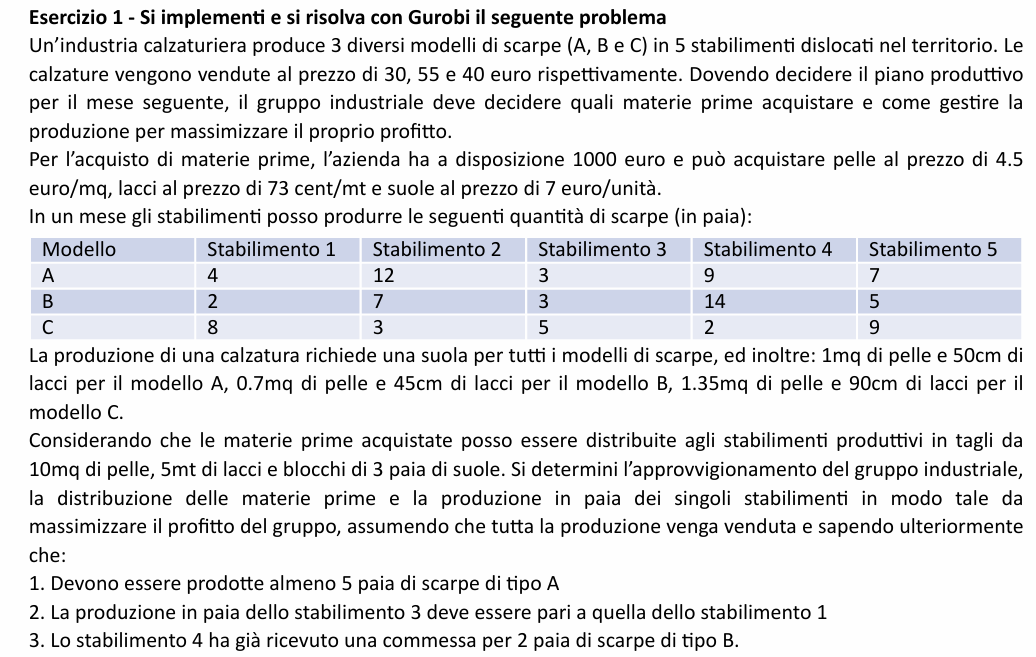

In [83]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

model = gp.Model()

t = model.addVars(3, lb=0, ub=GRB.INFINITY, name="t")
d = model.addMVar((3,5), lb=0, name="d")
x = model.addMVar((3,5), lb=0, name="x")

model.update()

c = np.array([4.5, 0.73, 7])
p = np.array([30, 55, 40])
tab = np.array([[2, 1.4, 2.7],
                [1, 0.9, 1.8],
                [2, 2, 2]])
q = np.array([[4, 12, 3, 9, 7],
              [2, 7, 3, 14, 5],
              [8, 3, 5, 2, 9]])

model.addConstr( gp.quicksum(c[i] * t[i] for i in range(3)) <= 1000)
for i in range(3):
    model.addConstr( gp.quicksum(d[i,j]  for j in range(5)) == t[i])

for i in range(3):
    for j in range(5):
        model.addConstr(x[i,j] <= q[i,j])

for i in range(3):
    for j in range(5):
        model.addConstr( gp.quicksum(tab[i,m] * x[m,j] for m in range(3) ) == d[i,j])

model.addConstr( gp.quicksum(x[0,j] for j in range(5)) >= 5)
model.addConstr( (gp.quicksum(x[i,0] for i in range(3)) - gp.quicksum(x[i,2] for i in range(3)))  == 0)
model.addConstr(x[1,3] >= 2)

model.setObjective(gp.quicksum(x[i,j] * p[i] for i in range(3) for j in range(5)), GRB.MAXIMIZE)
model.optimize()

for i in model.getVars():
    print(i.varName, i.x)
print(model.ObjVal)






Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 37 rows, 33 columns and 108 nonzeros (Max)
Model fingerprint: 0x6810df8b
Model has 15 linear objective coefficients
Coefficient statistics:
  Matrix range     [7e-01, 7e+00]
  Objective range  [3e+01, 6e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+00, 1e+03]

Presolve removed 34 rows and 24 columns
Presolve time: 0.02s
Presolved: 3 rows, 9 columns, 18 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.6244214e+03   1.838670e+02   0.000000e+00      0s
       4    2.1924352e+03   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.02 seconds (0.00 work units)
Optimal objective  2.192435188e+03
t[0] 76.1768751820565
t[1] 48.084583454704344
t[2] 88.8717593941159


![Screenshot 2026-07-20 155109.png](<attachment:Screenshot 2026-07-20 155109.png>)
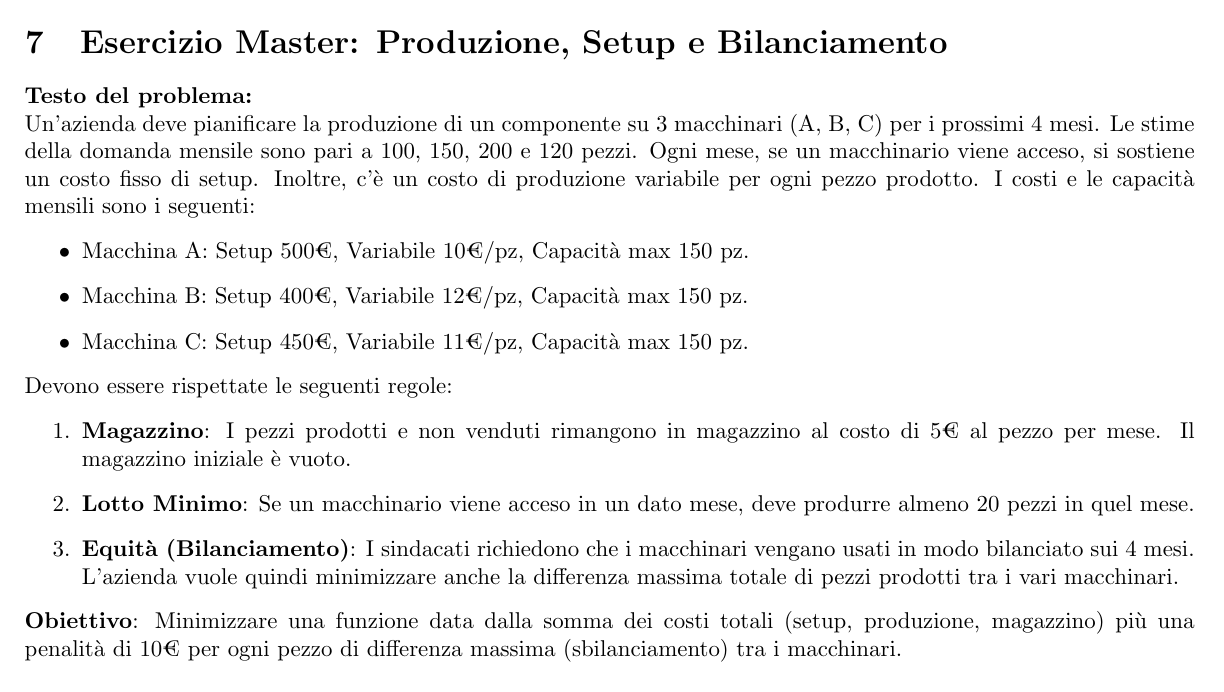

In [61]:
import gurobipy as gp
import numpy as np
from gurobipy import GRB 

model = gp.Model()

x = model.addMVar((3,4), lb=0, name='x')
y = model.addMVar((2,4), lb=0, name='y')
d12 = model.addVar(lb=0)
d13 = model.addVar(lb=0)
d14 = model.addVar(lb=0)
d23 = model.addVar(lb=0)
d24 = model.addVar(lb=0)
d34 = model.addVar(lb=0)


model.update()
m_s = np.array([100, 150, 200, 120])
m = np.array([500, 400, 450])
c = np.array([10, 12, 11])
k = np.array([150, 150, 150])



model.addConstr(d12 >= gp.quicksum(x[i,0] for i in range(3)) - gp.quicksum(x[i,1] for i in range(3)))
model.addConstr(d12 >= gp.quicksum(x[i,1] for i in range(3)) - gp.quicksum(x[i,0] for i in range(3)))

model.addConstr(d13 >= gp.quicksum(x[i,0] for i in range(3)) - gp.quicksum(x[i,2] for i in range(3)))
model.addConstr(d13 >= gp.quicksum(x[i,2] for i in range(3)) - gp.quicksum(x[i,0] for i in range(3)))

model.addConstr(d14 >= gp.quicksum(x[i,0] for i in range(3)) - gp.quicksum(x[i,3] for i in range(3)))
model.addConstr(d14 >= gp.quicksum(x[i,3] for i in range(3)) - gp.quicksum(x[i,0] for i in range(3)))

model.addConstr(d23 >= gp.quicksum(x[i,1] for i in range(3)) - gp.quicksum(x[i,2] for i in range(3)))
model.addConstr(d23 >= gp.quicksum(x[i,2] for i in range(3)) - gp.quicksum(x[i,1] for i in range(3)))

model.addConstr(d24 >= gp.quicksum(x[i,1] for i in range(3)) - gp.quicksum(x[i,3] for i in range(3)))
model.addConstr(d24 >= gp.quicksum(x[i,3] for i in range(3)) - gp.quicksum(x[i,1] for i in range(3)))

model.addConstr(d34 >= gp.quicksum(x[i,2] for i in range(3)) - gp.quicksum(x[i,3] for i in range(3)))
model.addConstr(d34 >= gp.quicksum(x[i,3] for i in range(3)) - gp.quicksum(x[i,2] for i in range(3)))


model.setObjective(gp.quicksum(x[i,j] * c[i] for i in range(3) for j in range(4)) + gp.quicksum(m[i] for i in range(3)) +
                   5 * gp.quicksum(y[1,j] for j in range(4)) + 10 * ( d12 + d13 + d14 + d23 + d24 + d34))


model.optimize()

for i in model.getVars():
    print(i.varName, i.x)
print(model.ObjVal)






Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 12 rows, 26 columns and 84 nonzeros (Min)
Model fingerprint: 0x821fecdf
Model has 22 linear objective coefficients and an objective constant of 1350
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 1e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [0e+00, 0e+00]

Presolve removed 12 rows and 26 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.3500000e+03   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.350000000e+03
x[0,0] 0.0
x[0,1] 0.0
x[0,2] 0.0
x[0,3] 0.0
x[1,0] 0.0
x[1,1] 0.0
x[1,2] 0.0
x[1,3] 0.0
x[2,0] 0.0
x[2

![Screenshot 2026-07-21 011454.png](<attachment:Screenshot 2026-07-21 011454.png>)
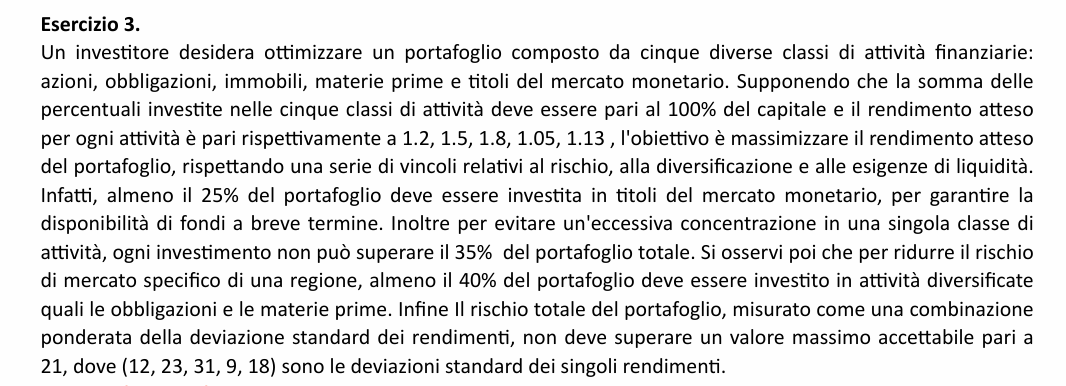

In [98]:
model = gp.Model()
x= model.addVars(5, lb=0)
model.update()
r = np.array([1.2, 1.5, 1.8, 1.05, 1.13])
d = np.array([12, 23, 31, 9, 18])

model.addConstr(gp.quicksum(x[i] for i in range(5)) == 1)
model.addConstr(x[4] >= 0.25 * gp.quicksum(x[j] for j in range(5)))
for i in range(5):
    model.addConstr(x[i] <= 0.35 * gp.quicksum(x[j] for j in range(5)))

model.addConstr(x[1] + x[3] >= 0.40 * gp.quicksum(x[j] for j in range(5)))
model.addConstr(gp.quicksum(x[j] * d[j] for j in range(5)) <= 21)

model.setObjective(gp.quicksum(x[i] * r[i] for i in range(5)), GRB.MAXIMIZE)

model.optimize()
for i in model.getVars():
    print(i.VarName, i.x)
print(model.ObjVal)


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 9 rows, 5 columns and 45 nonzeros (Max)
Model fingerprint: 0xe5d204c8
Model has 5 linear objective coefficients
Coefficient statistics:
  Matrix range     [3e-01, 3e+01]
  Objective range  [1e+00, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+01]

Presolve time: 0.01s
Presolved: 9 rows, 5 columns, 45 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.2325000e+30   7.812500e+30   2.232500e+00      0s
       6    1.4000000e+00   0.000000e+00   0.000000e+00      0s

Solved in 6 iterations and 0.02 seconds (0.00 work units)
Optimal objective  1.400000000e+00
C0 0.15000000000000002
C1 0.35000000000000003
C2 0.2
C3 0.049999999999999926
C4 0.25
1.4000000000000001


![Screenshot 2026-07-21 015124.png](<attachment:Screenshot 2026-07-21 015124.png>)
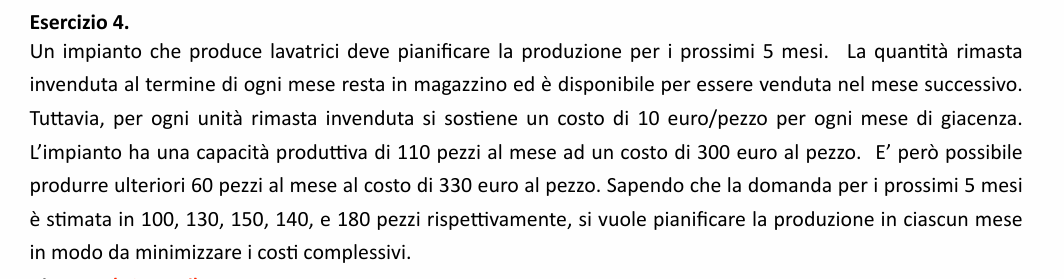

In [122]:
modell = gp.Model()
x = modell.addVars(5, lb=0, name='x', vtype=GRB.INTEGER)
y = modell.addVars(5, lb=0, name='y', vtype=GRB.INTEGER)
p = modell.addVars(5, lb=0, name='p', vtype=GRB.INTEGER)
modell.update()

d = np.array([100, 130, 150, 140, 180])

for i in range(5):
    modell.addConstr(x[i] <= 110)

for i in range(5):
    modell.addConstr(p[i] <= 60)

# --
# for i in range(5):
#     if i >= 1: 
#         modell.addConstr(x[i] + y[i-1] == x[i] + p[i])
#     else:
#         modell.addConstr(x[i] + p[i] == d[i] + y[i])
for i in range(5):
    if i == 0:
        modell.addConstr(x[i] + p[i] == d[i] + y[i])
    else:
        modell.addConstr(y[i-1] + x[i] + p[i] == d[i] + y[i])
# --    

modell.setObjective(10 * gp.quicksum(y[i] for i in range(5)) + 300 * gp.quicksum(x[i] for i in range(5)) +
                   330 * gp.quicksum(p[i] for i in range(5)), GRB.MINIMIZE) 

modell.optimize()
for i in modell.getVars():
    print(i.VarName, i.X)
print(modell.ObjVal)   


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 15 rows, 15 columns and 29 nonzeros (Min)
Model fingerprint: 0x5a79a007
Model has 15 linear objective coefficients
Variable types: 0 continuous, 15 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+01, 3e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+01, 2e+02]

Found heuristic solution: objective 217300.00000
Presolve removed 11 rows and 5 columns
Presolve time: 0.00s
Presolved: 4 rows, 10 columns, 13 nonzeros
Variable types: 0 continuous, 10 integer (0 binary)
Found heuristic solution: objective 215500.00000

Root relaxation: objective 2.147000e+05, 6 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |  

![Screenshot 2026-07-21 032731.png](<attachment:Screenshot 2026-07-21 032731.png>)
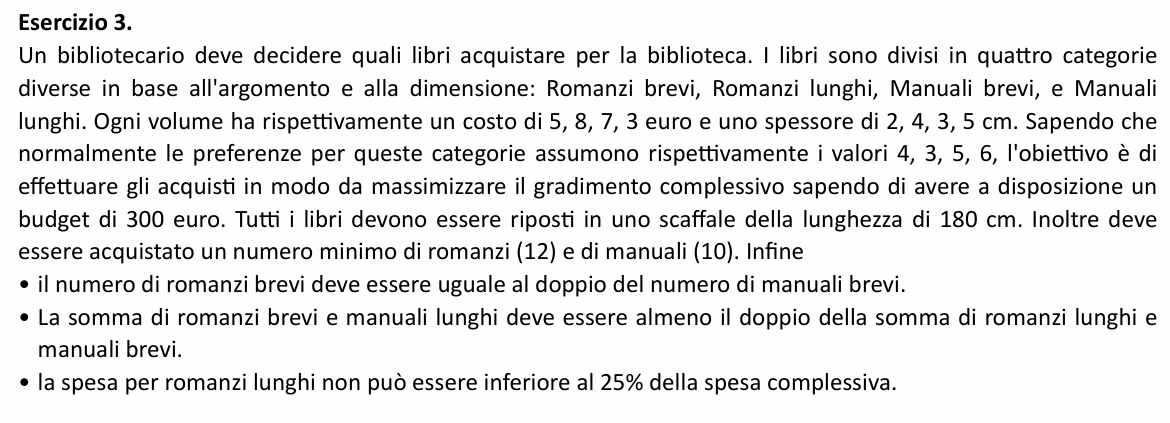

In [137]:
model = gp.Model()
x=model.addVars(4, lb=0, name='x', vtype=GRB.INTEGER)
model.update()

c = np.array([5, 8, 7, 3])
p = np.array([4, 3, 5, 6])
s = np.array([2, 4, 3, 5])

model.addConstr(gp.quicksum(x[i] * c[i] for i in range(4)) <= 300)
model.addConstr(gp.quicksum(x[i] * s[i] for i in range(4)) <= 180)
model.addConstr(x[0] + x[1] >= 12)
model.addConstr(x[2] + x[3] >= 10)
model.addConstr(x[0] == 2 * x[2])
model.addConstr(x[0] + x[3] >= 2 * (x[1] + x[2]))
model.addConstr(8 * x[1] >= 0.25 * gp.quicksum(x[i] * c[i] for i in range(4)) )

model.setObjective(gp.quicksum(x[i] * p[i] for i in range(4)), GRB.MAXIMIZE)
model.optimize()
for i in model.getVars():
    print(i.VarName, i.X)
print(model.ObjVal)  


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 7 rows, 4 columns and 22 nonzeros (Max)
Model fingerprint: 0x42195c29
Model has 4 linear objective coefficients
Variable types: 0 continuous, 4 integer (0 binary)
Coefficient statistics:
  Matrix range     [8e-01, 8e+00]
  Objective range  [3e+00, 6e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 3e+02]

Presolve removed 1 rows and 1 columns
Presolve time: 0.00s
Presolved: 6 rows, 3 columns, 15 nonzeros
Variable types: 0 continuous, 3 integer (0 binary)
Found heuristic solution: objective 118.0000000
Found heuristic solution: objective 140.0000000
Found heuristic solution: objective 169.0000000
Found heuristic solution: objective 192.0000000

Root relaxation: objective 2.418132e+02, 4 iterations, 0.00 secon

![Screenshot 2026-07-21 041059.png](<attachment:Screenshot 2026-07-21 041059.png>)
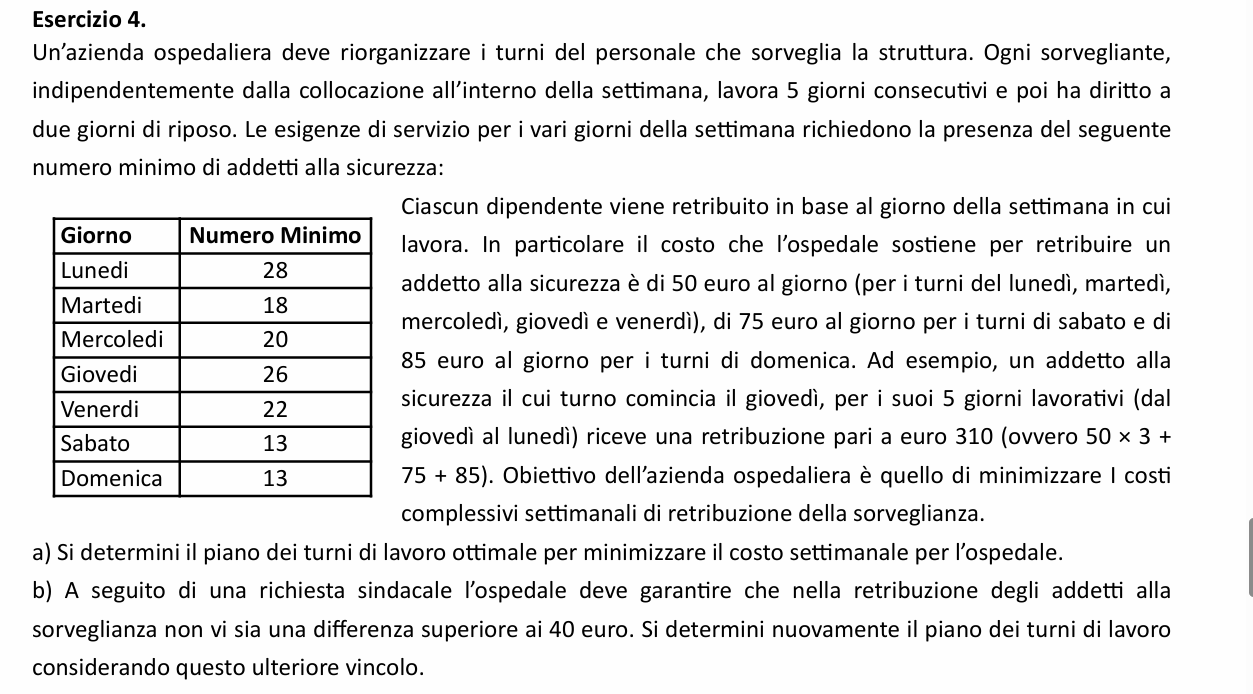

In [12]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

model = gp.Model()

# jours : 0=lundi, ..., 6=dimanche
J = range(7)

# besoin minimum par jour
m = np.array([28, 18, 20, 26, 22, 13, 13])

# coût d'un tour selon le jour de départ
p = np.array([250, 275, 310, 310, 310, 310, 285])

# x[i] = nombre d'employés qui commencent le tour le jour i
x = model.addVars(7, lb=0, vtype=GRB.INTEGER, name="x")

# contraintes de couverture
for j in J:
    model.addConstr(
        gp.quicksum(x[(j - i + 7) % 7] for i in range(5)) >= m[j],
        name=f"coverage_{j}"
    )

# objectif
model.setObjective(
    gp.quicksum(p[i] * x[i] for i in J),
    GRB.MINIMIZE
)

model.optimize()

if model.status == GRB.OPTIMAL:
    for i in J:
        print(f"x[{i}] =", x[i].X)
    print("Costo totale =", model.ObjVal)
else:
    print("Pas de solution optimale. Status =", model.status)

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 7 rows, 7 columns and 35 nonzeros (Min)
Model fingerprint: 0x308bf8a6
Model has 7 linear objective coefficients
Variable types: 0 continuous, 7 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+02, 3e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 3e+01]

Found heuristic solution: objective 14230.000000
Presolve time: 0.01s
Presolved: 7 rows, 7 columns, 35 nonzeros
Variable types: 0 continuous, 7 integer (0 binary)

Root relaxation: objective 8.030000e+03, 5 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0  

## STESSO ESERCIZIO

In [ ]:
from math import cos

import gurobipy as gp
from gurobipy import GRB
import numpy as np

model = gp.Model()

x = model.addVars(7, lb=0)
model.update()

Num_min = np.array([28, 18, 20, 26, 22, 13, 13])
costo = np.array([250, 275, 310, 310, 310, 310, 285])

model.addConstr(gp.quicksum(x[i] for i in ([0,3,4,5,6])) >= 28)
model.addConstr(gp.quicksum(x[i] for i in ([0,1,4,5,6])) >= 18)
model.addConstr(gp.quicksum(x[i] for i in ([0,1,2,5,6])) >= 20)
model.addConstr(gp.quicksum(x[i] for i in ([0,1,2,3,6])) >= 26)
model.addConstr(gp.quicksum(x[i] for i in ([0,1,2,3,4])) >= 22)
model.addConstr(gp.quicksum(x[i] for i in ([1,2,3,4,5])) >= 13)
model.addConstr(gp.quicksum(x[i] for i in ([2,3,4,5,6])) >= 13)

model.setObjective(gp.quicksum(x[i] * costo[i] for i in range(7)))
model.optimize()

## domanda b-1: ---------
model.addConstr(x[0]+x[1] >= 28)
model.addConstr(x[0]+x[1]+x[6] >= 18)
model.addConstr(x[0]+x[1]+x[6] >= 20)
model.addConstr(x[0]+x[1]+x[6] >= 26)
model.addConstr(x[0]+x[1] >= 22)
model.addConstr(x[1] >= 13)
model.addConstr(x[6] >= 13)
model.setObjective(250*x[0] + 275*x[1] + 285*x[6])
model.optimize()
# -----
# b-2:
model.addConstr(gp.quicksum(x[i] for i in ([3,4,5,6])) >= 28)
model.addConstr(gp.quicksum(x[i] for i in ([1,4,5,6])) >= 18)
model.addConstr(gp.quicksum(x[i] for i in ([1,2,5,6])) >= 20)
model.addConstr(gp.quicksum(x[i] for i in ([1,2,3,6])) >= 26)
model.addConstr(gp.quicksum(x[i] for i in ([1,2,3,4])) >= 22)
model.addConstr(gp.quicksum(x[i] for i in ([1,2,3,4,5])) >= 13)
model.addConstr(gp.quicksum(x[i] for i in ([2,3,4,5,6])) >= 13)
model.setObjective(gp.quicksum(x[i] * costo[i] for i in range(1,6)))
model.optimize()
#

for i in model.getVars():
    print(i.VarName, i.X)
print(model.ObjVal)  


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520U with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 7 rows, 7 columns and 35 nonzeros (Min)
Model fingerprint: 0x8ced7bb2
Model has 7 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+02, 3e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 3e+01]

Presolve time: 0.01s
Presolved: 7 rows, 7 columns, 35 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.400000e+02   0.000000e+00      0s
       5    8.0300000e+03   0.000000e+00   0.000000e+00      0s

Solved in 5 iterations and 0.02 seconds (0.00 work units)
Optimal objective  8.030000000e+03
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7520